# Machine Learning for CICY 4-Folds

H. Erbin, R. Finotello

Following the analysis in [arXiv:2007.13379](https://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](https://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds.
The idea is to see whether the Inception network can also be applied in higher dimensions.

## Inception Network

In this notebook we build a model of the Inception network and apply it to the configuration matrix of CICY 4-folds.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
from nn_tools.utils.plotutils import *
from nn_tools.utils.dirstruct import list_models
from nn_tools.nn_models.models import *

## Restore Working Directory

We restore the working directories.

In [2]:
img_dir = './img/inception_cnnaux_20201215_095534'
mod_dir = './models/inception_cnnaux_20201215_095534'

## Load the Parameters

We have to restore the training parameters for inference:

In [3]:
with open(os.path.join(mod_dir, 'parameters.json')) as f:
    parameters = json.load(f)

## Load the Data

We then load the data from file:

In [4]:
X_train = joblib.load(os.path.join(mod_dir, 'X_train.joblib'))
X_val   = joblib.load(os.path.join(mod_dir, 'X_val.joblib'))
X_test  = joblib.load(os.path.join(mod_dir, 'X_test.joblib'))
    
y_train = joblib.load(os.path.join(mod_dir, 'y_train.joblib'))
y_val   = joblib.load(os.path.join(mod_dir, 'y_val.joblib'))
y_test  = joblib.load(os.path.join(mod_dir, 'y_test.joblib'))

In [11]:
def py_to_tex(label):
    '''
    Print in TeX form the label.
    
    Required argument:
        label: the string containing the Hodge number label to print in TeX format.
    '''
    
    return f'$h^{{ {label[1]}, {label[2]} }}$'

## Reload Best Weights and Compute the Predictions

We then reload the best weights and compute the predictions of the model in test mode.

In [5]:
models = list_models(list(y_train.keys()), root=mod_dir)

In [6]:
predictions = {'training':   {key: mod.predict(X_train) for key, mod in models.items()},
               'validation': {key: mod.predict(X_val) for key, mod in models.items()},
               'test':       {key: mod.predict(X_test) for key, mod in models.items()},
              }
joblib.dump(predictions, os.path.join(mod_dir, 'inception_predictions.joblib.gz'), compress=9)

['./models/inception_cnnaux_20201215_095534/inception_predictions.joblib.gz']

In [7]:
true_values = {'training':   dict(y_train),
               'validation': dict(y_val),
               'test':       dict(y_test),
              }
joblib.dump(true_values, os.path.join(mod_dir, 'inception_ground_truth.joblib.gz'), compress=9)

['./models/inception_cnnaux_20201215_095534/inception_ground_truth.joblib.gz']

In [8]:
residuals = {fold: {model: \
                    {label: predictions[fold][model][label].reshape(-1,) - true_values[fold][label].reshape(-1,) \
                            for label in predictions[fold][model].keys()
                    } for model in predictions[fold].keys()
                   } for fold in predictions.keys()
            }
joblib.dump(predictions, os.path.join(mod_dir, 'inception_residuals.joblib.gz'), compress=9)

['./models/inception_cnnaux_20201215_095534/inception_residuals.joblib.gz']

## Visualise the Predictions

We can finally visualise the results of the different models.

In [9]:
labels = ['h11', 'h21', 'h31', 'h22']

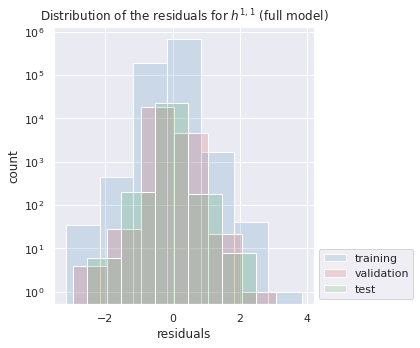

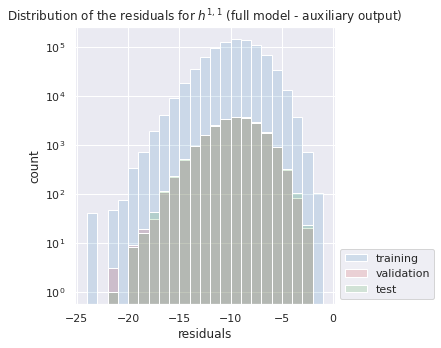

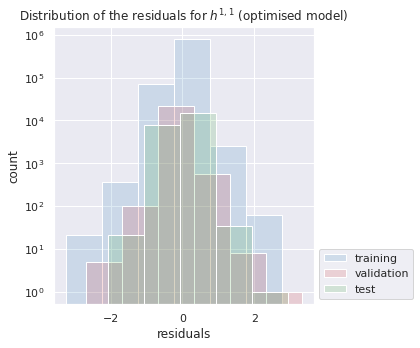

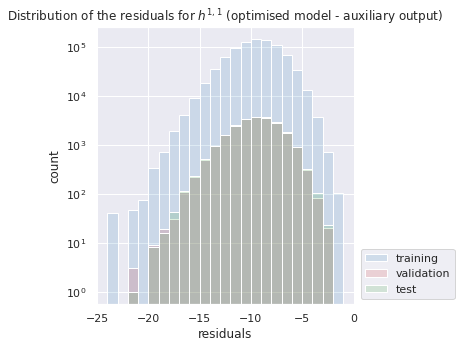

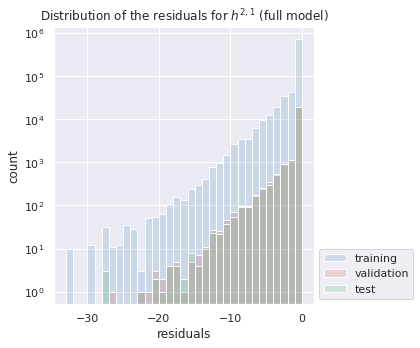

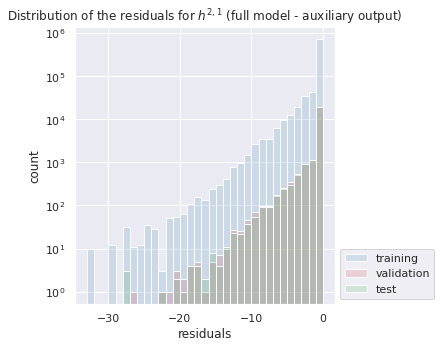

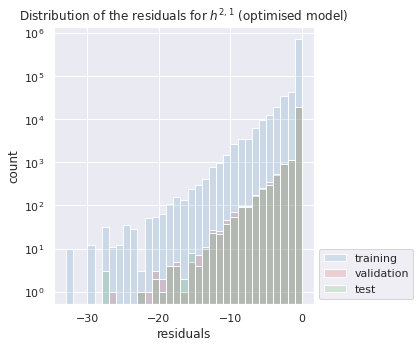

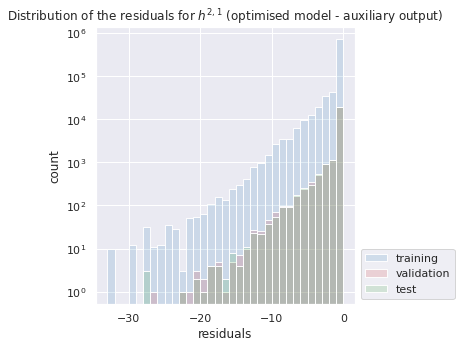

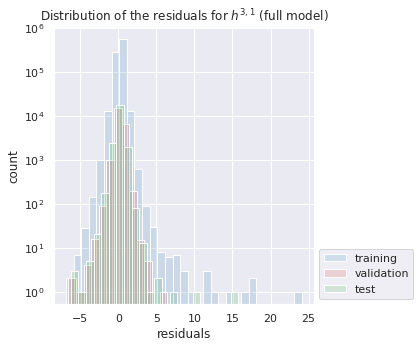

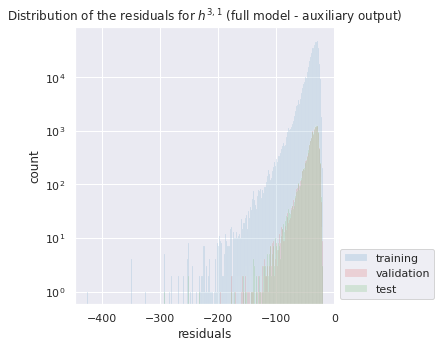

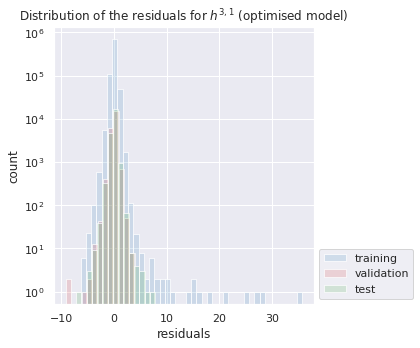

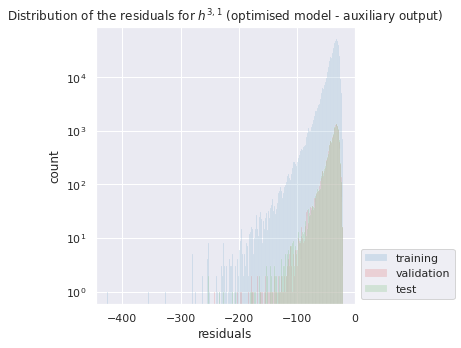

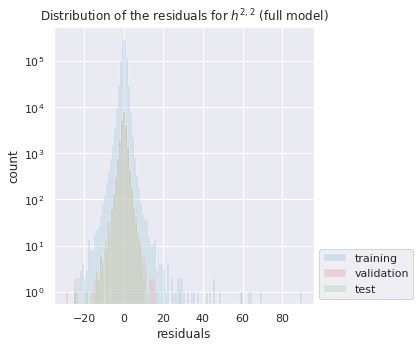

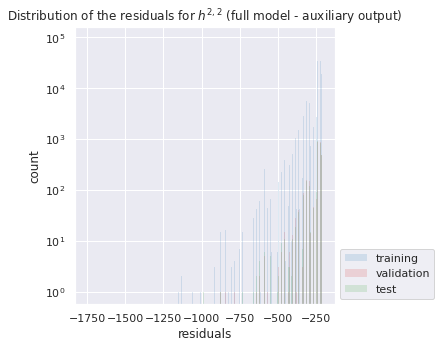

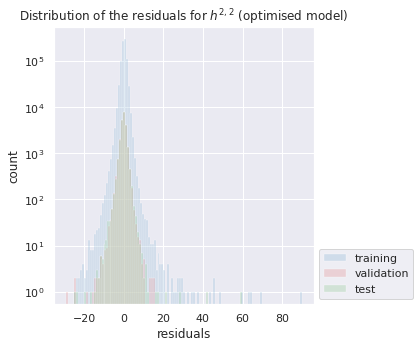

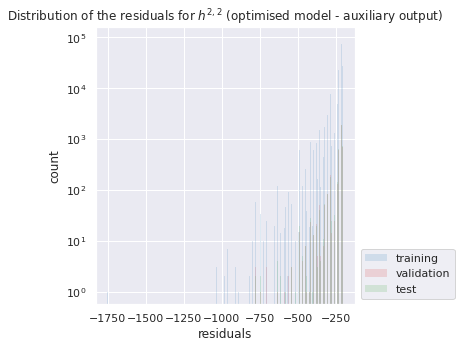

In [22]:
for label in labels:
    
    # plot full model
    data = {key: residuals[key]['full_model'][label] for key in residuals}
    
    plot_univariate(data=data,
                    out_name='inception_full_model_' + label + '_residuals',
                    root=img_dir,
                    binwidth=1,
                    title=f'Distribution of the residuals for {py_to_tex(label)} (full model)',
                    xlabel='residuals',
                    ylabel='count',
                    yscale='log',
                    stat='count',
                    base_ratio=(1,1),
                    show=True,
                    save_pdf=True
                   )
    
    # plot auxiliary output
    if parameters['aux_output']:
        
        data_aux = {key: residuals[key]['full_model'][label + '_' + parameters['aux_suff']] for key in residuals}
    
        plot_univariate(data=data_aux,
                        out_name='inception_full_model_' + label + '_' + parameters['aux_suff'] + '_residuals',
                        root=img_dir,
                        binwidth=1,
                        title=f'Distribution of the residuals for {py_to_tex(label)} (full model - auxiliary output)',
                        xlabel='residuals',
                        ylabel='count',
                        yscale='log',
                        stat='count',
                        base_ratio=(1,1),
                        show=True,
                        save_pdf=True
                       )
        
    # plot optimised model
    data_opt = {key: residuals[key][label][label] for key in residuals}
    
    plot_univariate(data=data_opt,
                    out_name='inception_full_model_' + label + '_residuals',
                    root=img_dir,
                    binwidth=1,
                    title=f'Distribution of the residuals for {py_to_tex(label)} (optimised model)',
                    xlabel='residuals',
                    ylabel='count',
                    yscale='log',
                    stat='count',
                    base_ratio=(1,1),
                    show=True,
                    save_pdf=True
                   )
    
    # plot auxiliary output
    if parameters['aux_output']:
        
        data_opt_aux = {key: residuals[key][label][label + '_' + parameters['aux_suff']] for key in residuals}
    
        plot_univariate(data=data_opt_aux,
                        out_name='inception_full_model_' + label + '_' + parameters['aux_suff'] + '_residuals',
                        root=img_dir,
                        binwidth=1,
                        title=f'Distribution of the residuals for {py_to_tex(label)} (optimised model - auxiliary output)',
                        xlabel='residuals',
                        ylabel='count',
                        yscale='log',
                        stat='count',
                        base_ratio=(1,1),
                        show=True,
                        save_pdf=True
                       )

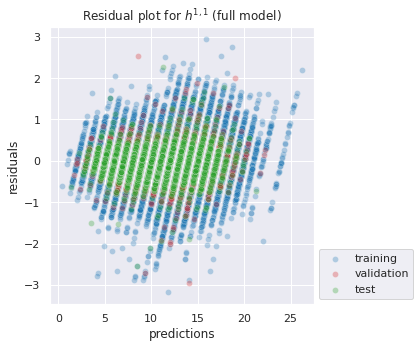

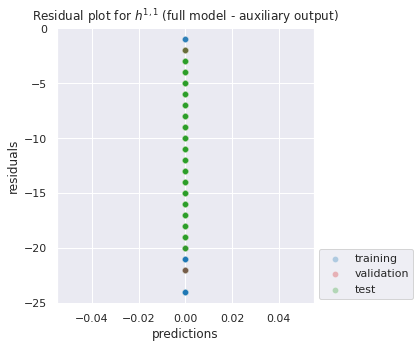

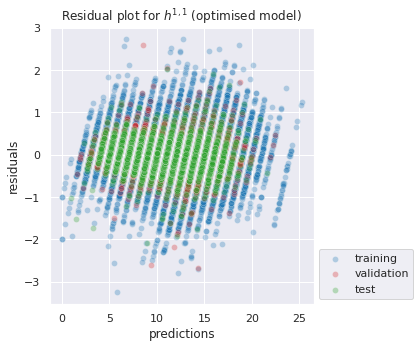

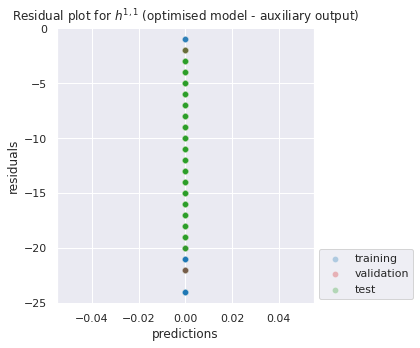

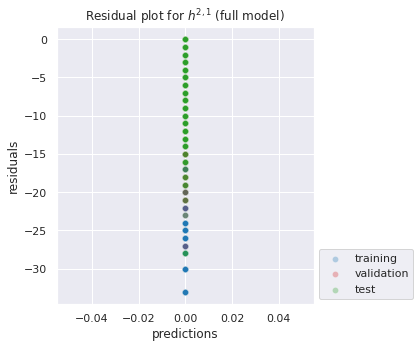

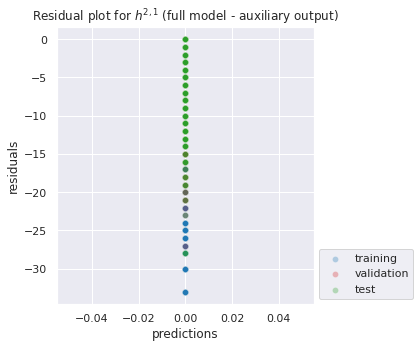

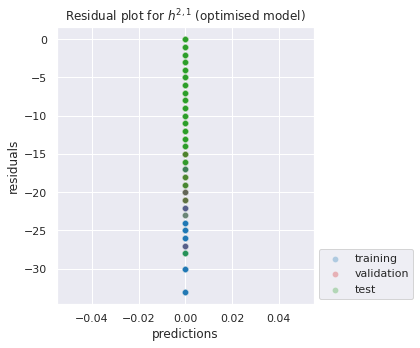

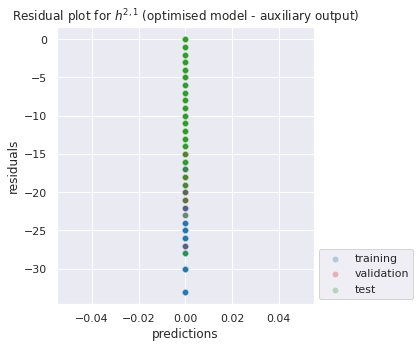

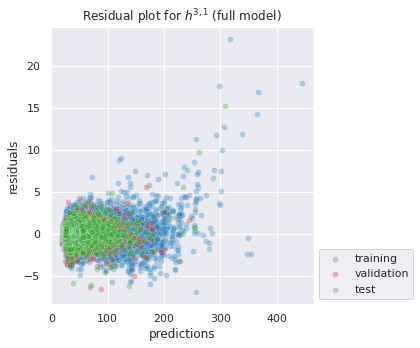

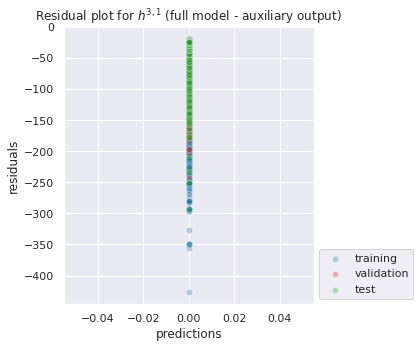

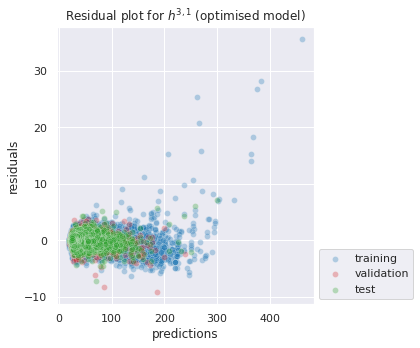

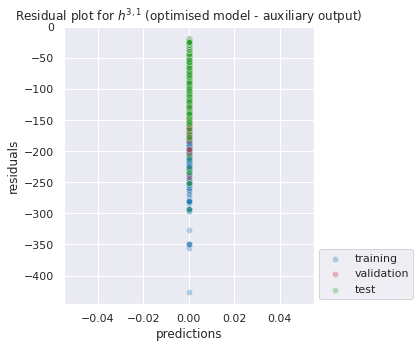

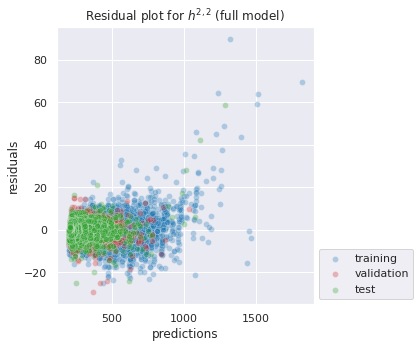

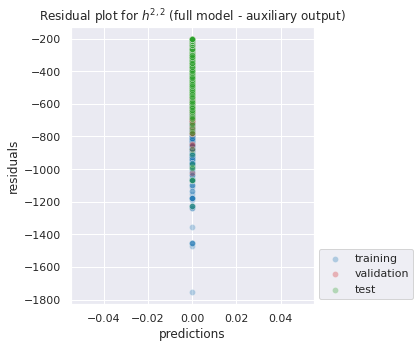

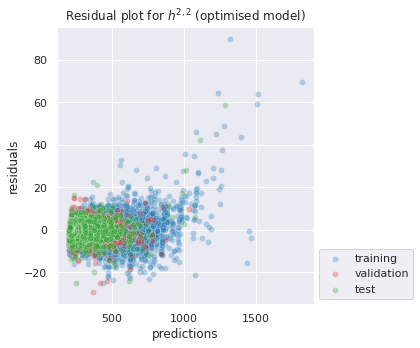

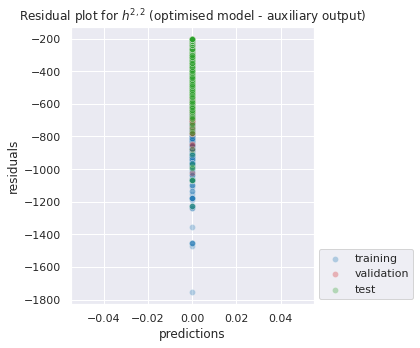

In [31]:
for label in labels:
    
    # plot full model
    data = {key: {'predictions': predictions[key]['full_model'][label].reshape(-1,),
                  'residuals':   residuals[key]['full_model'][label].reshape(-1,)
                 } for key in ['training', 'validation', 'test']
           }
    
    plot_bivariate(data=data,
                   x='predictions',
                   y='residuals',
                   out_name='inception_full_model_' + label + '_resplot',
                   root=img_dir,
                   title=f'Residual plot for {py_to_tex(label)} (full model)',
                   xlabel='predictions',
                   ylabel='residuals',
                   show=True,
                   save_pdf=True
                  )
    
    # plot auxiliary output
    if parameters['aux_output']:
        
        data_aux = {key: {'predictions': predictions[key]['full_model'][label + '_' + parameters['aux_suff']].reshape(-1,),
                          'residuals':   residuals[key]['full_model'][label + '_' + parameters['aux_suff']].reshape(-1,)
                         } for key in ['training', 'validation', 'test']
                   }
    
        plot_bivariate(data=data_aux,
                       x='predictions',
                       y='residuals',
                       out_name='inception_full_model_' + label + '_' + parameters['aux_suff'] + '_resplot',
                       root=img_dir,
                       title=f'Residual plot for {py_to_tex(label)} (full model - auxiliary output)',
                       xlabel='predictions',
                       ylabel='residuals',
                       show=True,
                       save_pdf=True
                      )
        
    # plot optimised model
    data = {key: {'predictions': predictions[key][label][label].reshape(-1,),
                  'residuals':   residuals[key][label][label].reshape(-1,)
                 } for key in ['training', 'validation', 'test']
           }
    
    plot_bivariate(data=data,
                   x='predictions',
                   y='residuals',
                   out_name='inception_full_model_' + label + '_resplot',
                   root=img_dir,
                   title=f'Residual plot for {py_to_tex(label)} (optimised model)',
                   xlabel='predictions',
                   ylabel='residuals',
                   show=True,
                   save_pdf=True
                  )
    
    # plot auxiliary output
    if parameters['aux_output']:
        
        data_aux = {key: {'predictions': predictions[key][label][label + '_' + parameters['aux_suff']].reshape(-1,),
                          'residuals':   residuals[key][label][label + '_' + parameters['aux_suff']].reshape(-1,)
                         } for key in ['training', 'validation', 'test']
                   }
    
        plot_bivariate(data=data_aux,
                       x='predictions',
                       y='residuals',
                       out_name='inception_full_model_' + label + '_' + parameters['aux_suff'] + '_resplot',
                       root=img_dir,
                       title=f'Residual plot for {py_to_tex(label)} (optimised model - auxiliary output)',
                       xlabel='predictions',
                       ylabel='residuals',
                       show=True,
                       save_pdf=True
                      )

## Compute the Metrics

We finally compute the metrics of the model.

In [13]:
metrics = {fold: \
           {model: \
            {'mse':       {label: np.mean(np.square(residuals[fold][model][label]))
                           for label in predictions[fold][model].keys()
                          },
             'mae':       {label: np.mean(np.abs(residuals[fold][model][label]))
                           for label in predictions[fold][model].keys()
                          },
             'acc_rint':  {label: np.equal(true_values[fold][label],
                                           np.rint(predictions[fold][model][label].reshape(-1,)).astype(np.int)
                                          ).mean()
                           for label in predictions[fold][model].keys()
                          },
             'acc_floor': {label: np.equal(true_values[fold][label],
                                          np.floor(predictions[fold][model][label].reshape(-1,)).astype(np.int)
                                         ).mean()
                           for label in predictions[fold][model].keys()
                          },
             'acc_ceil':  {label: np.equal(true_values[fold][label],
                                          np.ceil(predictions[fold][model][label].reshape(-1,)).astype(np.int)
                                         ).mean()
                           for label in predictions[fold][model].keys()
                          },
            } for model in predictions[fold].keys()
           } for fold in predictions.keys()
          }
joblib.dump(true_values, os.path.join(mod_dir, 'inception_metrics.joblib.gz'), compress=9)

['./models/inception_cnnaux_20201215_095534/inception_metrics.joblib.gz']

In [14]:
with open(os.path.join(mod_dir, 'metrics.txt'), 'w') as out_file:
    for file in [sys.stdout, out_file]:
        for folds, models_dict in metrics.items():
            print('\n=====================', file=file)
            print(f'{folds.upper()}:', file=file)
            print('=====================', file=file)
            for mod, metrics_dict in models_dict.items():
                print(f'\n  {mod}:', file=file)
                print('  ___________________', file=file)
                for met, labels_dict in metrics_dict.items():
                    print(f'\n    > {met.upper()}:', file=file)
                    for lab, met_value in labels_dict.items():
                        print(f'      * {lab.lower()}: {met_value:.3f}', file=file)


TRAINING:

  full_model:
  ___________________

    > MSE:
      * h11: 0.034
      * h21: 4.211
      * h31: 0.236
      * h22: 1.788
      * h11_aux: 107.183
      * h21_aux: 4.211
      * h31_aux: 1752.407
      * h22_aux: 60457.552

    > MAE:
      * h11: 0.132
      * h21: 0.817
      * h31: 0.374
      * h22: 0.934
      * h11_aux: 10.065
      * h21_aux: 0.817
      * h31_aux: 39.550
      * h22_aux: 240.826

    > ACC_RINT:
      * h11: 0.982
      * h21: 0.701
      * h31: 0.740
      * h22: 0.381
      * h11_aux: 0.000
      * h21_aux: 0.701
      * h31_aux: 0.000
      * h22_aux: 0.000

    > ACC_FLOOR:
      * h11: 0.326
      * h21: 0.701
      * h31: 0.750
      * h22: 0.345
      * h11_aux: 0.000
      * h21_aux: 0.701
      * h31_aux: 0.000
      * h22_aux: 0.000

    > ACC_CEIL:
      * h11: 0.672
      * h21: 0.701
      * h31: 0.213
      * h22: 0.311
      * h11_aux: 0.000
      * h21_aux: 0.701
      * h31_aux: 0.000
      * h22_aux: 0.000

  h11:
  _____________